# Exploration

## Initializations

In [1]:
# Remove the hash sign from the line below and run the cell to install the package for plotting
# !pip install git+https://github.com/garrettj403/SciencePlots

In [2]:
from pint import UnitRegistry
# Imports from
from process_engineering_toolkit.stream import Stream
from process_engineering_toolkit.reactors.pfr import PFR
from process_engineering_toolkit.rate_laws import MassActionRateLaw, PowerLawRateLaw
from process_engineering_toolkit.reactions import Reactions

# Plotting
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

## Stream definition

In [3]:
# # This will raise an error as mole fractions must be non-negative
# s1 = Stream("Fresh A", 10, {"A": -1, "B": 0.5}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

In [4]:
# # This will raise an error as compositions must sum to 1
# s1 = Stream("Fresh A", 10, {"A": 0.7, "B": 0.2}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

# inlet = Flow([s1, s2])
# print(inlet.total_flows())

In [5]:
# s1 = Stream("Fresh A", 10, {"A": 0.8, "B": 0.2})
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

## README clean

Equilibrium conversion: 0.5759007764246823
Conversion at 0.5 m^3: 0.35107232393465604
Required PFR volume [m3]: 0.6315620359590592


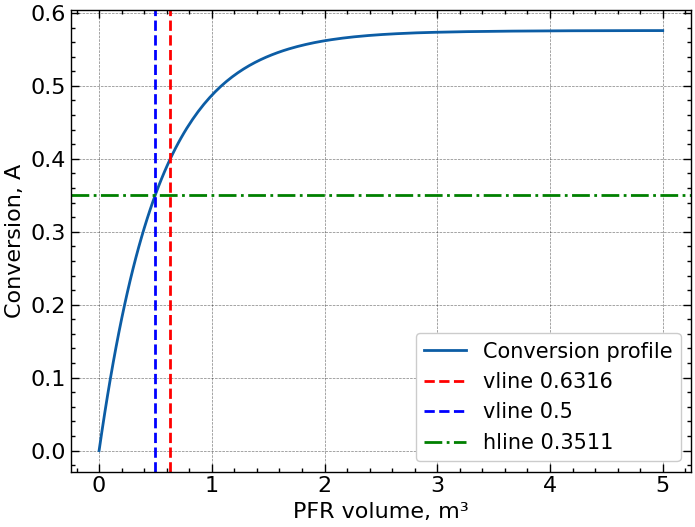

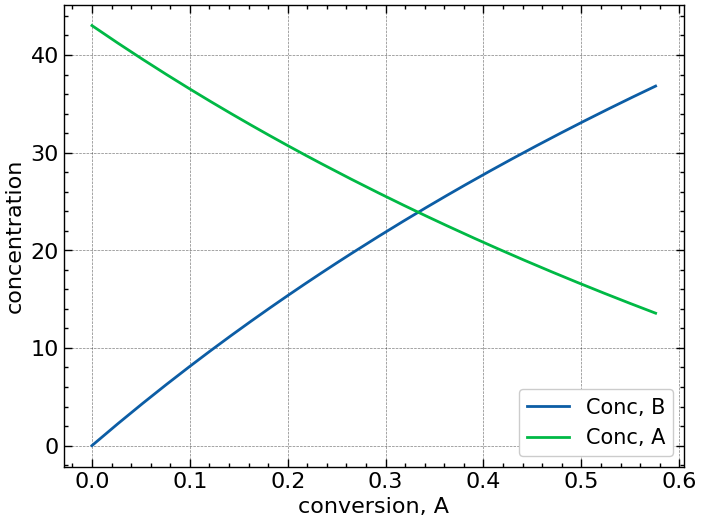

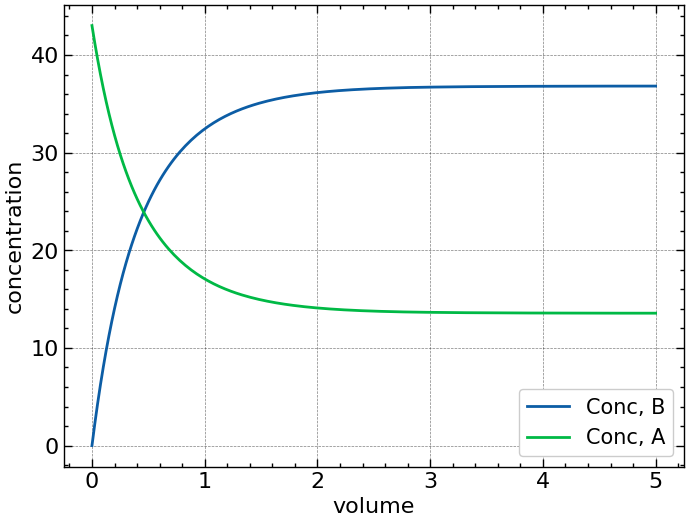

In [6]:
# Define reactions
reactions = [
    {"equation": "A <-> 2B", "rate_law": "mass_action", "parameters": {"kf": 0.3, "kb": 0.003}}
    ]

# Instantiate a Reactions obj
rxns = Reactions(reactions)

# Define Inlet Streams
s1 = Stream("Fresh A", 20, {"A": 0.6, "I": 0.4})

# Define parameters for PFR reactor
parameters = {
    "phase": "gas",  # or "liquid"
    "T": 340,
    "P": 2*101325
}

# Instantiate PFR object
pfr = PFR(rxns, inlet_streams=s1, parameters=parameters) # s1 should not have to be an iterable when there is only 1 stream

# Determine equilibrium conversion
Xeq = pfr.equilibrium_conversion("A")
print("Equilibrium conversion:", Xeq)

# Solve PFR: 0-5 m3
pfr.solve(V_span = (0,5))

# Determine achievable conversion at specific volume: 0.5 m3
X = pfr.conversion_at_volume("A", 0.5)
print("Conversion at 0.5 m^3:", X)

# Determine volume required for 40% conversion of species A
V_req = pfr.volume_for_conversion("A", 0.4)
print("Required PFR volume [m3]:", V_req)

# Determine profiles
profile = pfr.profile("A")

plt.plot(profile["volume"], profile["conversion"], label="Conversion profile")
# Add vertical lines
plt.axvline(x=0.6315620359590592, color='red', linestyle='--', label='vline 0.6316')
plt.axvline(x=0.5, color='blue', linestyle='--', label='vline 0.5')
# Add horizontal line
plt.axhline(y=0.35106832033662927, color='green', linestyle='-.', label='hline 0.3511')
# Labels and legend
plt.xlabel("PFR volume, m³")
plt.ylabel("Conversion, A")
plt.legend(loc='lower right', fontsize=15)
plt.show()

plt.plot(profile["conversion"], profile["concentration"]["B"], label="Conc, B")
plt.plot(profile["conversion"], profile["concentration"]["A"], label="Conc, A")
plt.xlabel("conversion, A")
plt.ylabel("concentration")
plt.legend(loc='lower right', fontsize=15)
plt.show()

plt.plot(profile["volume"], profile["concentration"]["B"], label="Conc, B")
plt.plot(profile["volume"], profile["concentration"]["A"], label="Conc, A")
plt.xlabel("volume")
plt.ylabel("concentration")
plt.legend(loc='lower right', fontsize=15)
plt.show()

## For README

In [7]:
# Define reactions
reactions = [
    {
        "equation": "A <-> 2B",
        "rate_law": "mass_action",
        "parameters": {"kf": 0.3, "kb": 0.003},
    },
    # {
    #     "equation": "C -> D",
    #     "rate_law": "power",
    #     "parameters": {"expression": "kf*C^2", "kf": 0.2},
    # },
]

# A Reactions object is instantiated
rxns = Reactions(reactions)
print(f"Species: {rxns.species}")
print(f"Stoichiometric Matrix: {rxns.SM}")
print(f"Reactant orders: {rxns.reactant_orders}")
print(f"Product orders: {rxns.product_orders}")


Species: ['A', 'B']
Stoichiometric Matrix: [[-1.]
 [ 2.]]
Reactant orders: [[ 1.]
 [-0.]]
Product orders: [[0.]
 [2.]]


In [8]:
# Define Inlet Streams
s1 = Stream("Fresh A", 20, {"A": 0.6, "I": 0.4})
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

print(s1.flows)
# print(s2.flows)

{'A': 12.0, 'I': 8.0}


### PFR Class ###
Species: ['A', 'B', 'I']
SM: [[-1.]
 [ 2.]
 [ 0.]]
Inlet vector: [12.  0.  8.]
Equilibrium conversion: 0.5759007764246823
Conversion at 0.5 m^3: 0.35107232393465604
Required PFR volume [m3]: 0.6315620359590592


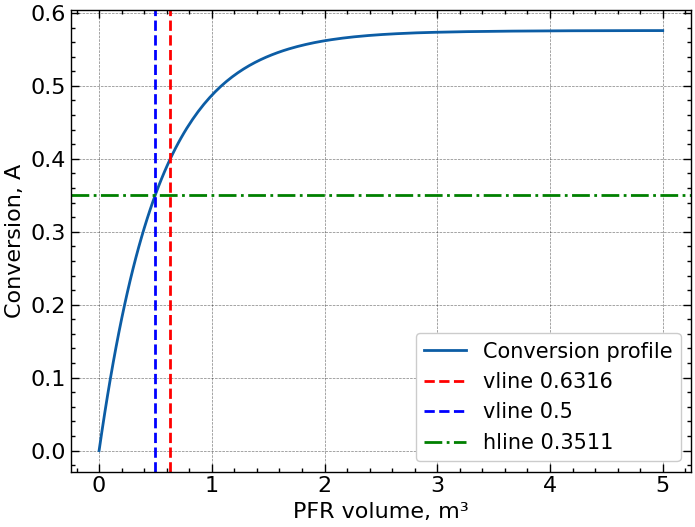

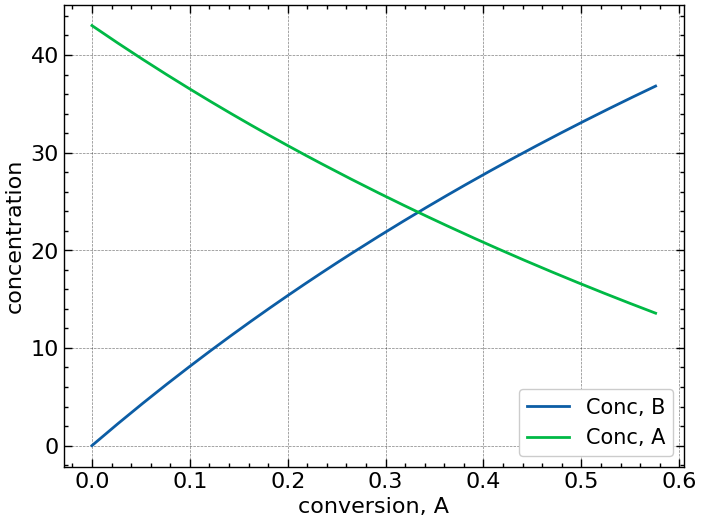

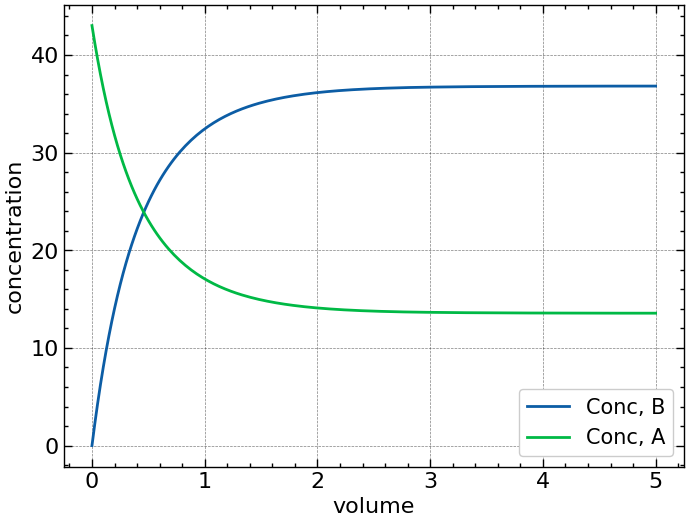

In [9]:
# Define parameters for PFR reactor
parameters = {
    "phase": "gas",  # or "liquid"
    "T": 340,
    "P": 2*101325
}

# Instantiate PFR object
pfr = PFR(rxns, inlet_streams=[s1], parameters=parameters) # s1 should not have to be an iterable when there is only 1 stream
print("### PFR Class ###")
print(f"Species: {pfr.species}")
print(f"SM: {pfr.SM}")
print(f"Inlet vector: {pfr.build_inlet_vector()}")

# Determine equilibrium conversion
Xeq = pfr.equilibrium_conversion("A")
print("Equilibrium conversion:", Xeq)

# Solve PFR: 0-5 m3
pfr.solve(V_span = (0,5))

# Determine achievable conversion at specific volume: 0.5 m3
X = pfr.conversion_at_volume("A", 0.5)
print("Conversion at 0.5 m^3:", X)

# Determine volume required for 40% conversion of species A
V_req = pfr.volume_for_conversion("A", 0.4)
print("Required PFR volume [m3]:", V_req)

# Determine profiles
profile = pfr.profile("A")

plt.plot(profile["volume"], profile["conversion"], label="Conversion profile")
# Add vertical lines
plt.axvline(x=0.6315620359590592, color='red', linestyle='--', label='vline 0.6316')
plt.axvline(x=0.5, color='blue', linestyle='--', label='vline 0.5')
# Add horizontal line
plt.axhline(y=0.35106832033662927, color='green', linestyle='-.', label='hline 0.3511')
# Labels and legend
plt.xlabel("PFR volume, m³")
plt.ylabel("Conversion, A")
plt.legend(loc='lower right', fontsize=15)
plt.show()

plt.plot(profile["conversion"], profile["concentration"]["B"], label="Conc, B")
plt.plot(profile["conversion"], profile["concentration"]["A"], label="Conc, A")
plt.xlabel("conversion, A")
plt.ylabel("concentration")
plt.legend(loc='lower right', fontsize=15)
plt.show()

plt.plot(profile["volume"], profile["concentration"]["B"], label="Conc, B")
plt.plot(profile["volume"], profile["concentration"]["A"], label="Conc, A")
plt.xlabel("volume")
plt.ylabel("concentration")
plt.legend(loc='lower right', fontsize=15)
plt.show()

## Mass Action vs Power Law testing

### Setup

In [ ]:
import numpy as np
from process_engineering_toolkit.reactions import Reaction
from process_engineering_toolkit.rate_laws import MassActionRateLaw, PowerLawRateLaw

# Species
species_list = ["A", "B", "C"]
species_index = {s: i for i, s in enumerate(species_list)}

# Stoichiometry
stoichiometry = {
    "A": -1,
    "B": -1,
    "C": 1
}

# Concentrations (mol/L)
C = np.array([2.0, 1.5, 0.0])
T = 350  # K

Mass action rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Rate determination: Irreversibel reaction

In [13]:
# Mass Action (elementary reaction)
params_mass_action = {
    "kf": 0.5
}

ma = MassActionRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, ma)
rxn._compile(species_index)

print("Mass action rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Mass action rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [14]:
# Power Law
params_power_law = {
    "expression": "A * B",
    "kf": 0.5
}

pl = PowerLawRateLaw(stoichiometry, **params_power_law)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power law rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Rate determination: Reversible reaction

In [15]:
C = np.array([2.0, 1.5, 0.5])
T = 350

In [16]:
# Mass Action (elementary reaction)
params_mass_action = {
    "kf": 0.5,
    "kb": 0.1,
}

ma = MassActionRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, ma)
rxn._compile(species_index)

print("Mass action rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Mass action rate: 1.45
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [19]:
# Power law
params_mass_action = {
    "expression": "A * B - C",
    "kf": 0.5,
    "kb": 0.1,
}

pl = PowerLawRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power Law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power Law rate: 1.45
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Non-integer orders (Power Law only)

In [25]:
params_power_law = {
    "expression": "A^0.5 * B^1.2 - C^1.5",
    "kf": 0.5,
    "kb": 0.1,
}

pl = PowerLawRateLaw(stoichiometry, **params_power_law)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power Law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power Law rate: 1.1149006760695908
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [26]:
print(0.5*C[0]**(0.5)*C[1]**(1.2) - 0.1*C[2]**1.5)

1.1149006760695908


### Arrhenius test

In [ ]:
params_mass_action = {
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

ma = MassActionRateLaw(stoichiometry, species_list, **params_mass_action)

print("Mass action Arrhenius rate:", ma.rate(C, T))

Mass action Arrhenius rate: 3.448570123742299e-05


In [10]:
for T in [300, 350, 400]:
    print(T, ma.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


In [11]:
params_power_law = {
    "expression": "A * B",
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

pl = PowerLawRateLaw(stoichiometry, species_list, **params_power_law)

print("Power law Arrhenius rate:", pl.rate(C, 350))

Power law Arrhenius rate: 0.00010345710371226898


In [12]:
for T in [300, 350, 400]:
    print(T, pl.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


### Edge cases: Invalid usage

In [13]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * B",
    kb=0.1  # ← should trigger validation
)

ValueError: Backward rate constants provided but expression has no backward term

In [14]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * D",  # D not in species_list
    kf=1.0
)

ValueError: Unknown species in rate expression: D

In [23]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="a**(1/2) * B",  # Invalid math symbol (for simplicity, division symbol not allowed)
    kf=1.0
)

ValueError: Invalid exponent in factor a^(1/2)